# Unit 6: Correlation Coefficients

Updated for BME2202-2026

本次演示的主线：

1. 先画散点图，再计算相关系数。
2. 以 Pearson 相关为主，完成“描述量 + 总体推断 + 结果汇报”的完整流程。
3. 用 Spearman $\rho$ 和 Kendall $\tau$ 作为扩展：同样报告估计值、p 值、适用条件和解释边界。
4. 在 BrainInjury 数据中观察一个重要问题：重复测量数据不能简单合并后当作独立样本。


In [1]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
pd.set_option("display.precision", 3)

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)


def find_data_file(filename: str) -> Path:
    # Preferred use: keep the CSV file in the same folder as this notebook.
    # The absolute fallbacks keep the teacher copy runnable on the course
    # machine even if the data files have not yet been copied into the 2026
    # folder.

    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path.cwd() / "data" / filename,
        Path("/Users/tongair/Documents/Teaching/BME2202-2026/Unit 6- Correlation Coefficients") / filename,
        Path("/Users/tongair/Documents/Teaching/BME2202-2025") / filename,
        Path("/Users/tongair/Documents/Teaching/BME2202-2025/Unit7-2") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Cannot find {filename}. Put it next to this notebook or update find_data_file()."
    )


def clean_course_csv(path: Path) -> pd.DataFrame:
    # Remove the unnamed index column produced by R/Pandas exports.
    df = pd.read_csv(path)
    unnamed_cols = [col for col in df.columns if col.startswith("Unnamed:")]
    return df.drop(columns=unnamed_cols)


## Demo 6-0: 散点图先行

Pearson 相关系数只描述**线性共同变化**。在计算 $r$ 之前，先看散点图：

- 是否大致线性？
- 是否有强异常值？
- 两个变量是否都是连续变量？
- 每个点是否能近似看成独立观测？


In [2]:
mtcars = clean_course_csv(find_data_file("mtcars.csv"))
numeric_cols = ["mpg", "cyl", "disp", "hp", "drat", "wt", "qsec"]

display(mtcars.head())
print(f"Rows: {mtcars.shape[0]}, columns: {mtcars.shape[1]}")


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


Rows: 32, columns: 11


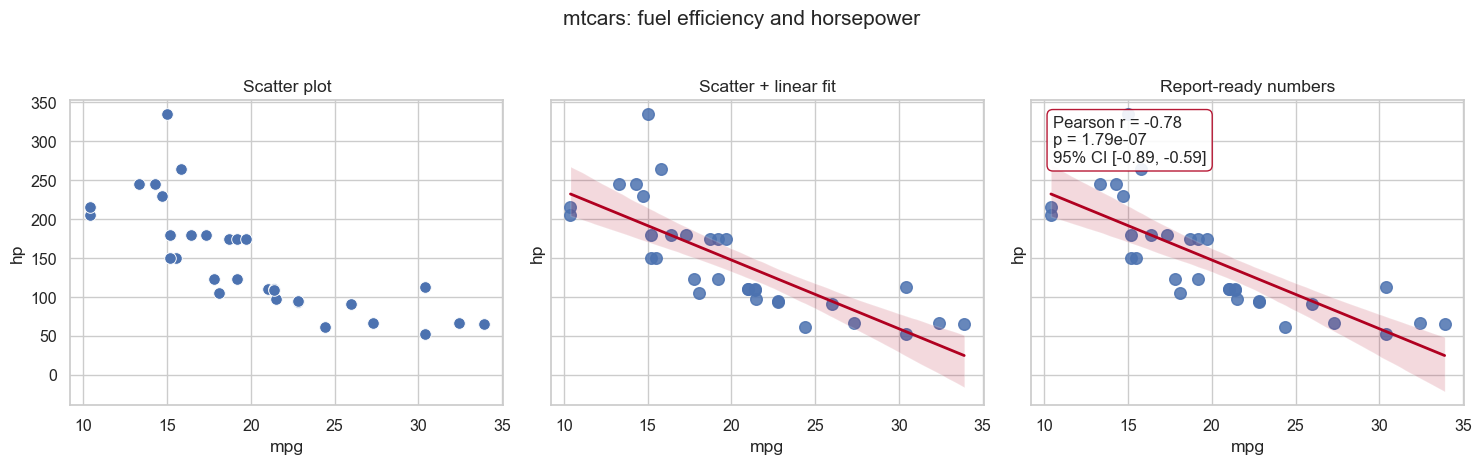

In [3]:
result = stats.pearsonr(mtcars["mpg"], mtcars["hp"])
ci = result.confidence_interval(confidence_level=0.95)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

sns.scatterplot(data=mtcars, x="mpg", y="hp", s=70, ax=axes[0])
axes[0].set_title("Scatter plot")

sns.regplot(
    data=mtcars,
    x="mpg",
    y="hp",
    scatter_kws={"s": 70, "alpha": 0.85},
    line_kws={"color": "#b00020", "lw": 2},
    ax=axes[1],
)
axes[1].set_title("Scatter + linear fit")

sns.regplot(
    data=mtcars,
    x="mpg",
    y="hp",
    scatter_kws={"s": 70, "alpha": 0.85},
    line_kws={"color": "#b00020", "lw": 2},
    ax=axes[2],
)
axes[2].text(
    0.05,
    0.95,
    f"Pearson r = {result.statistic:.2f}\np = {result.pvalue:.3g}\n95% CI [{ci.low:.2f}, {ci.high:.2f}]",
    transform=axes[2].transAxes,
    va="top",
    fontsize=12,
    bbox={"boxstyle": "round,pad=0.35", "fc": "white", "ec": "#b00020", "alpha": 0.9},
)
axes[2].set_title("Report-ready numbers")

fig.suptitle("mtcars: fuel efficiency and horsepower", y=1.03, fontsize=15)
fig.tight_layout()


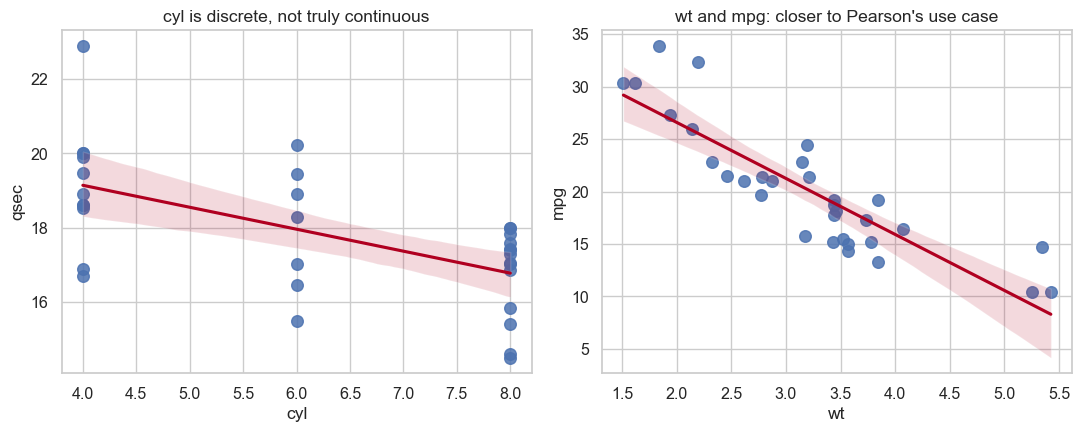

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.regplot(
    data=mtcars,
    x="cyl",
    y="qsec",
    scatter_kws={"s": 70, "alpha": 0.85},
    line_kws={"color": "#b00020"},
    ax=axes[0],
)
axes[0].set_title("cyl is discrete, not truly continuous")

sns.regplot(
    data=mtcars,
    x="wt",
    y="mpg",
    scatter_kws={"s": 70, "alpha": 0.85},
    line_kws={"color": "#b00020"},
    ax=axes[1],
)
axes[1].set_title("wt and mpg: closer to Pearson's use case")

fig.tight_layout()


## Demo 6-1: Covariance and Pearson correlation

样本协方差：

$$
s_{xy} = \frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}{n-1}
$$

协方差保留了变量单位，所以数值大小不容易跨研究比较。Pearson 相关系数把协方差标准化：

$$
r = \frac{s_{xy}}{s_xs_y}
$$

因此 $r$ 总在 $[-1, 1]$ 之间。


,covariance,correlation
x,1.063,1.000
y,0.703,0.679


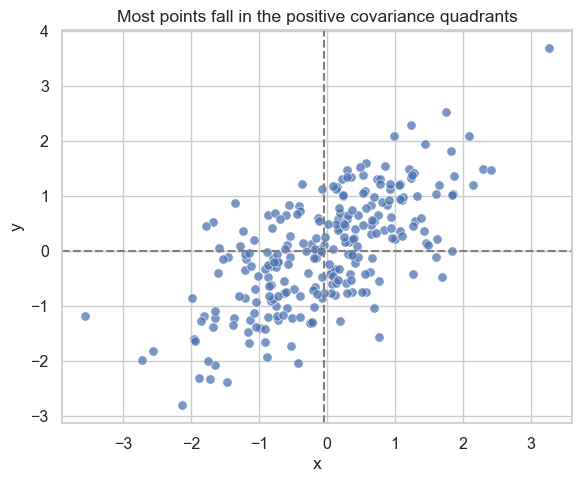

In [5]:
sim = rng.multivariate_normal(
    mean=[0, 0],
    cov=[[1, 0.72], [0.72, 1]],
    size=250,
)
sim = pd.DataFrame(sim, columns=["x", "y"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=sim, x="x", y="y", s=45, alpha=0.75, ax=ax)
ax.axvline(sim["x"].mean(), color="gray", lw=1.5, ls="--")
ax.axhline(sim["y"].mean(), color="gray", lw=1.5, ls="--")
ax.set_title("Most points fall in the positive covariance quadrants")
fig.tight_layout()

display(pd.DataFrame({"covariance": sim.cov().loc["x"], "correlation": sim.corr().loc["x"]}))


Covariance matrix for mpg and hp


,mpg,hp
mpg,36.324,-320.732
hp,-320.732,4700.867


Pearson correlation matrix


,mpg,cyl,disp,hp,drat,wt,qsec
mpg,1.000,-0.852,-0.848,-0.776,0.681,-0.868,0.419
cyl,-0.852,1.000,0.902,0.832,-0.700,0.782,-0.591
disp,-0.848,0.902,1.000,0.791,-0.710,0.888,-0.434
hp,-0.776,0.832,0.791,1.000,-0.449,0.659,-0.708
drat,0.681,-0.700,-0.710,-0.449,1.000,-0.712,0.091
wt,-0.868,0.782,0.888,0.659,-0.712,1.000,-0.175
qsec,0.419,-0.591,-0.434,-0.708,0.091,-0.175,1.000


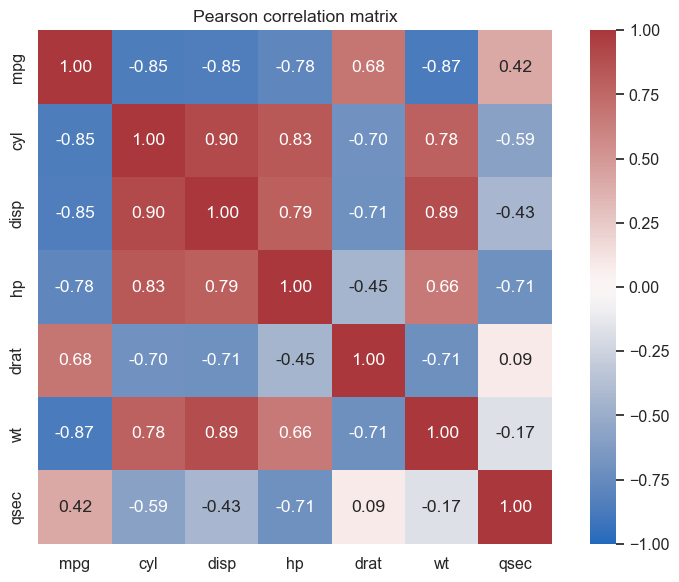

In [6]:
print("Covariance matrix for mpg and hp")
display(mtcars[["mpg", "hp"]].cov())

print("Pearson correlation matrix")
display(mtcars[numeric_cols].corr(method="pearson"))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    mtcars[numeric_cols].corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)
ax.set_title("Pearson correlation matrix")
fig.tight_layout()


## Demo 6-2: Pearson's $r$ with modern SciPy

`scipy.stats.pearsonr` 在新版 SciPy 中返回一个结果对象：

- `.statistic`：样本 Pearson 相关系数 $r$
- `.pvalue`：检验 $H_0:\rho=0$ 的 p 值
- `.confidence_interval()`：基于 Fisher $z$ 变换的置信区间

这里的总体参数写作 $\rho$。样本统计量写作 $r$。


In [7]:
x = mtcars["mpg"]
y = mtcars["hp"]

pearson = stats.pearsonr(x, y, alternative="two-sided")
pearson_ci = pearson.confidence_interval(confidence_level=0.95)

print(f"r = {pearson.statistic:.3f}")
print(f"p = {pearson.pvalue:.4g}")
print(f"95% CI = [{pearson_ci.low:.3f}, {pearson_ci.high:.3f}]")
print(f"df = n - 2 = {len(x) - 2}")


r = -0.776
p = 1.788e-07
95% CI = [-0.885, -0.586]
df = n - 2 = 30


In [8]:
def pearson_report(
    df: pd.DataFrame,
    x: str,
    y: str,
    confidence_level: float = 0.95,
    alternative: str = "two-sided",
) -> pd.Series:
    # Return a report-ready Pearson correlation summary.
    clean = df[[x, y]].dropna()
    result = stats.pearsonr(clean[x], clean[y], alternative=alternative)
    ci = result.confidence_interval(confidence_level=confidence_level)

    return pd.Series(
        {
            "x": x,
            "y": y,
            "n": len(clean),
            "r": result.statistic,
            "df": len(clean) - 2,
            "p": result.pvalue,
            f"{confidence_level:.0%} CI lower": ci.low,
            f"{confidence_level:.0%} CI upper": ci.high,
        }
    )


display(pearson_report(mtcars, "mpg", "hp").to_frame().T)
display(pearson_report(mtcars, "wt", "mpg").to_frame().T)


,x,y,n,r,df,p,95% CI lower,95% CI upper
0,mpg,hp,32,-0.776,30,0.0,-0.885,-0.586


,x,y,n,r,df,p,95% CI lower,95% CI upper
0,wt,mpg,32,-0.868,30,0.0,-0.934,-0.744


## Demo 6-3: Fisher $z$ transform and inference

Pearson 相关的常用显著性检验：

$$
t = \frac{r\sqrt{n-2}}{\sqrt{1-r^2}}, \quad df=n-2
$$

Fisher $z$ 变换：

$$
z = \frac{1}{2}\ln\left(\frac{1+r}{1-r}\right), \quad SE_z=\frac{1}{\sqrt{n-3}}
$$

Fisher $z$ 的目标是把 $r$ 的偏态抽样分布转成更接近正态的尺度，便于计算置信区间。


In [9]:
def fisher_z_ci(r: float, n: int, confidence_level: float = 0.95) -> tuple[float, float]:
    # Fisher-z confidence interval for Pearson's rho.
    if n <= 3:
        raise ValueError("Fisher-z CI for Pearson correlation requires n > 3.")

    r = np.clip(r, -0.999999, 0.999999)
    alpha = 1 - confidence_level
    z_crit = stats.norm.ppf(1 - alpha / 2)
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)

    low_z = z - z_crit * se
    high_z = z + z_crit * se
    return np.tanh(low_z), np.tanh(high_z)


manual_ci = fisher_z_ci(pearson.statistic, len(x), confidence_level=0.95)

print(f"SciPy CI  : [{pearson_ci.low:.3f}, {pearson_ci.high:.3f}]")
print(f"Manual CI : [{manual_ci[0]:.3f}, {manual_ci[1]:.3f}]")


SciPy CI  : [-0.885, -0.586]
Manual CI : [-0.885, -0.586]


Population rho in simulation is approximately 0.548.
Mean sample r = 0.537; mean Fisher z = 0.629.


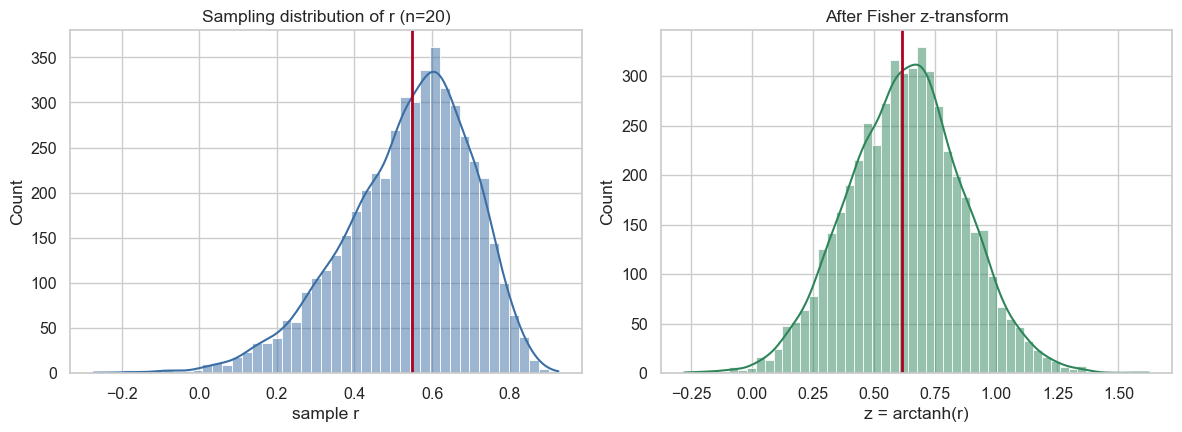

In [10]:
rho = 0.55
population_n = 20_000
population = rng.multivariate_normal(
    mean=[0, 0],
    cov=[[1, rho], [rho, 1]],
    size=population_n,
)
population = pd.DataFrame(population, columns=["x", "y"])
population_r = stats.pearsonr(population["x"], population["y"]).statistic

reps = 5_000
sample_n = 20
sample_r = np.empty(reps)

for i in range(reps):
    sample = population.sample(n=sample_n, replace=False, random_state=i)
    sample_r[i] = stats.pearsonr(sample["x"], sample["y"]).statistic

sample_z = np.arctanh(np.clip(sample_r, -0.999999, 0.999999))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(sample_r, kde=True, ax=axes[0], color="#3a6ea5")
axes[0].axvline(population_r, color="#b00020", lw=2)
axes[0].set_title(f"Sampling distribution of r (n={sample_n})")
axes[0].set_xlabel("sample r")

sns.histplot(sample_z, kde=True, ax=axes[1], color="#2f855a")
axes[1].axvline(np.arctanh(population_r), color="#b00020", lw=2)
axes[1].set_title("After Fisher z-transform")
axes[1].set_xlabel("z = arctanh(r)")

fig.tight_layout()
print(f"Population rho in simulation is approximately {population_r:.3f}.")
print(f"Mean sample r = {sample_r.mean():.3f}; mean Fisher z = {sample_z.mean():.3f}.")


## Demo 6-4: Conditions and diagnostic plots

计算 Pearson $r$ 本身很容易，但把样本 $r$ 推断到总体 $\rho$ 时，需要更谨慎：

1. 两个变量应为连续变量或近似连续变量。
2. 两个变量之间的关系应大致线性。
3. 观测值应相互独立。
4. 用 t 检验/Fisher-z CI 时，最好没有极端异常值，且总体关系近似二元正态。
5. $r=0$ 只表示“没有线性相关”，不等于“没有关系”。


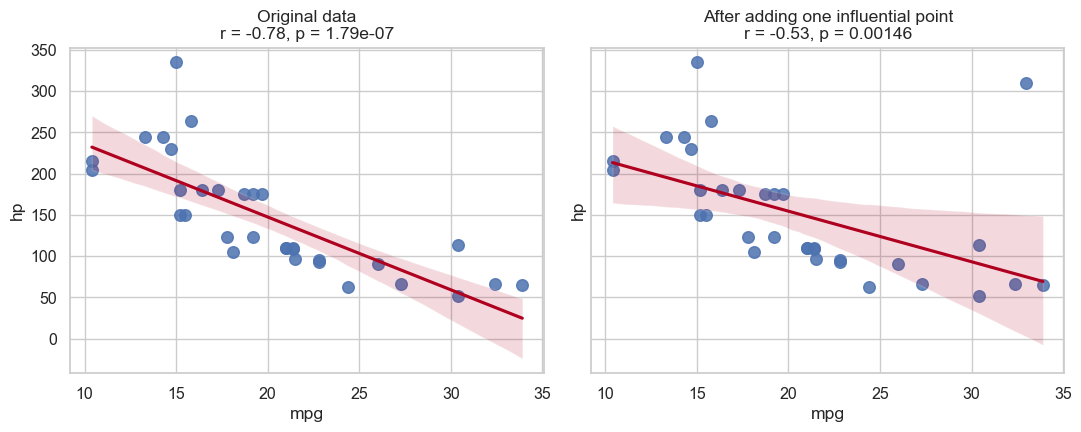

In [11]:
base = mtcars[["mpg", "hp"]].copy()
with_outlier = pd.concat(
    [base, pd.DataFrame({"mpg": [33], "hp": [310]})],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

for ax, frame, title in [
    (axes[0], base, "Original data"),
    (axes[1], with_outlier, "After adding one influential point"),
]:
    res = stats.pearsonr(frame["mpg"], frame["hp"])
    sns.regplot(
        data=frame,
        x="mpg",
        y="hp",
        scatter_kws={"s": 70, "alpha": 0.85},
        line_kws={"color": "#b00020"},
        ax=ax,
    )
    ax.set_title(f"{title}\nr = {res.statistic:.2f}, p = {res.pvalue:.3g}")

fig.tight_layout()


## Demo 6-5: Spearman $\rho$ and Kendall $\tau$

当关系是**单调但不线性**，或者变量本身是有序等级时，可以考虑秩相关：

- Spearman $\rho$：先把数据转成秩，再计算秩的 Pearson 相关。
- Kendall $\tau$：比较所有观测对的排序是否一致。

课堂重点：它们不是“更高级的 Pearson”，而是回答不同版本的问题。


,method,statistic,p,answers
0,Pearson r,0.939,7.508e-38,linear association
1,Spearman rho,0.974,9.218e-52,monotonic rank association
2,Kendall tau,0.881,6.086e-31,pairwise ordering agreement


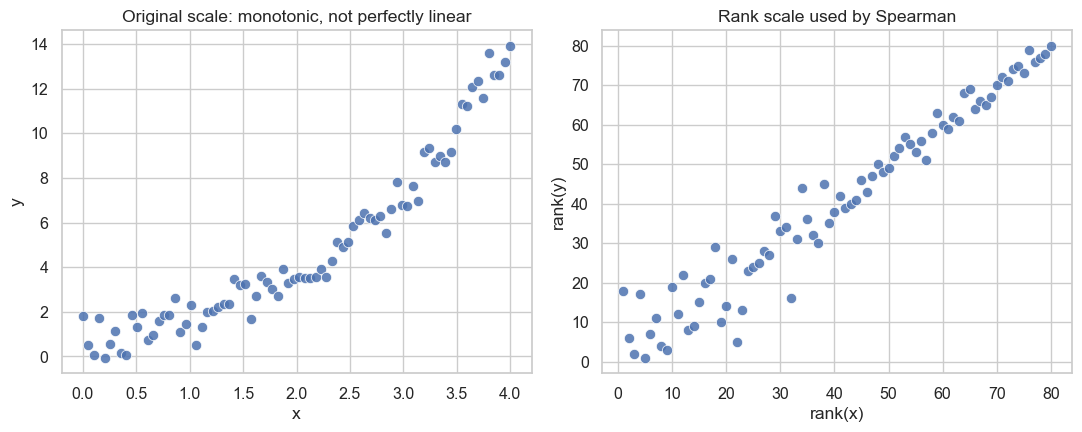

In [12]:
rank_demo = pd.DataFrame({"x": np.linspace(0, 4, 80)})
rank_demo["y"] = np.exp(rank_demo["x"] / 1.5) + rng.normal(0, 0.6, len(rank_demo))

summary = pd.DataFrame(
    [
        {
            "method": "Pearson r",
            "statistic": stats.pearsonr(rank_demo["x"], rank_demo["y"]).statistic,
            "p": stats.pearsonr(rank_demo["x"], rank_demo["y"]).pvalue,
            "answers": "linear association",
        },
        {
            "method": "Spearman rho",
            "statistic": stats.spearmanr(rank_demo["x"], rank_demo["y"]).statistic,
            "p": stats.spearmanr(rank_demo["x"], rank_demo["y"]).pvalue,
            "answers": "monotonic rank association",
        },
        {
            "method": "Kendall tau",
            "statistic": stats.kendalltau(rank_demo["x"], rank_demo["y"]).statistic,
            "p": stats.kendalltau(rank_demo["x"], rank_demo["y"]).pvalue,
            "answers": "pairwise ordering agreement",
        },
    ]
)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.scatterplot(data=rank_demo, x="x", y="y", s=55, alpha=0.85, ax=axes[0])
axes[0].set_title("Original scale: monotonic, not perfectly linear")

ranked = rank_demo.rank()
sns.scatterplot(data=ranked, x="x", y="y", s=55, alpha=0.85, ax=axes[1])
axes[1].set_title("Rank scale used by Spearman")
axes[1].set_xlabel("rank(x)")
axes[1].set_ylabel("rank(y)")

fig.tight_layout()


In [13]:
def correlation_summary(df: pd.DataFrame, x: str, y: str) -> pd.DataFrame:
    # Compare Pearson, Spearman and Kendall for the same pair of variables.
    clean = df[[x, y]].dropna()
    results = []

    pearson_result = stats.pearsonr(clean[x], clean[y])
    pearson_ci = pearson_result.confidence_interval(confidence_level=0.95)
    results.append(
        {
            "method": "Pearson r",
            "estimate": pearson_result.statistic,
            "p": pearson_result.pvalue,
            "95% CI": f"[{pearson_ci.low:.3f}, {pearson_ci.high:.3f}]",
            "best for": "linear association between continuous variables",
        }
    )

    spearman_result = stats.spearmanr(clean[x], clean[y])
    results.append(
        {
            "method": "Spearman rho",
            "estimate": spearman_result.statistic,
            "p": spearman_result.pvalue,
            "95% CI": "use bootstrap or large-sample approximation",
            "best for": "monotonic association or ordinal variables",
        }
    )

    kendall_result = stats.kendalltau(clean[x], clean[y])
    results.append(
        {
            "method": "Kendall tau",
            "estimate": kendall_result.statistic,
            "p": kendall_result.pvalue,
            "95% CI": "use bootstrap or large-sample approximation",
            "best for": "ordinal data; pairwise ordering agreement",
        }
    )

    return pd.DataFrame(results)


display(correlation_summary(mtcars, "mpg", "hp"))


,method,estimate,p,95% CI,best for
0,Pearson r,-0.776,1.788e-07,"[-0.885, -0.586]",linear association between continuous variables
1,Spearman rho,-0.895,5.086e-12,use bootstrap or large-sample approximation,monotonic association or ordinal variables
2,Kendall tau,-0.743,4.332e-09,use bootstrap or large-sample approximation,ordinal data; pairwise ordering agreement


## Demo 6-6: BrainInjury in-class practice

数据：

- `InjuryScore`：脑损伤严重指数，数值越低表示损伤越严重。
- `MemoryScore`：记忆认知评分，数值越高表示认知表现越好。
- `Subject`：病人编号。
- `Day`：检测时间。

练习目标：比较三种分析单位带来的结果差异。

1. 每一天单独分析：同一天 4 名病人的 Pearson 相关。
2. 先对每名病人 3 天取平均，再分析 4 名病人的 Pearson 相关。
3. 把 12 条记录直接合并分析。思考：这一步违反了什么条件？


In [14]:
brain = clean_course_csv(find_data_file("BrainInjury.csv"))
display(brain)

print(brain.dtypes)
print(f"Rows: {brain.shape[0]}, subjects: {brain['Subject'].nunique()}, days: {brain['Day'].nunique()}")


,InjuryScore,MemoryScore,Subject,Day
0,2.950,8.452,subject1,Day1
1,3.387,9.183,subject1,Day2
2,3.101,10.245,subject1,Day3
3,5.421,1.784,subject2,Day1
4,4.228,3.969,subject2,Day2
5,4.677,11.036,subject2,Day3
6,7.396,5.666,subject3,Day1
7,7.747,15.303,subject3,Day2
8,7.495,9.351,subject3,Day3
9,9.976,27.916,subject4,Day1


InjuryScore    float64
MemoryScore    float64
Subject         object
Day             object
dtype: object
Rows: 12, subjects: 4, days: 3


In [15]:
def plot_and_report_pearson(
    df: pd.DataFrame,
    x: str,
    y: str,
    *,
    title: str,
    ax=None,
    hue: str | None = None,
) -> pd.Series:
    # Draw a scatter/regression plot and return a report-ready Pearson summary.
    clean = df[[x, y] + ([hue] if hue else [])].dropna()
    result = stats.pearsonr(clean[x], clean[y])
    ci = result.confidence_interval(confidence_level=0.95)

    if ax is None:
        _, ax = plt.subplots(figsize=(5.5, 4.5))

    if hue:
        sns.scatterplot(data=clean, x=x, y=y, hue=hue, s=90, ax=ax)
        sns.regplot(
            data=clean,
            x=x,
            y=y,
            scatter=False,
            line_kws={"color": "#b00020", "lw": 2},
            ax=ax,
        )
        ax.legend(title=hue, bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        sns.regplot(
            data=clean,
            x=x,
            y=y,
            scatter_kws={"s": 90, "alpha": 0.9},
            line_kws={"color": "#b00020", "lw": 2},
            ax=ax,
        )

    ax.set_title(title)
    ax.text(
        0.03,
        0.97,
        f"n={len(clean)}\nr={result.statistic:.2f}\np={result.pvalue:.3g}",
        transform=ax.transAxes,
        va="top",
        fontsize=11,
        bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "gray", "alpha": 0.88},
    )

    return pd.Series(
        {
            "analysis": title,
            "n": len(clean),
            "r": result.statistic,
            "df": len(clean) - 2,
            "p": result.pvalue,
            "95% CI lower": ci.low,
            "95% CI upper": ci.high,
        }
    )


,analysis,n,r,df,p,95% CI lower,95% CI upper
0,Day1: 4 independent subjects,4,0.702,2,0.298,-0.796,0.993
1,Day2: 4 independent subjects,4,0.936,2,0.064,-0.248,0.999
2,Day3: 4 independent subjects,4,0.775,2,0.225,-0.729,0.995


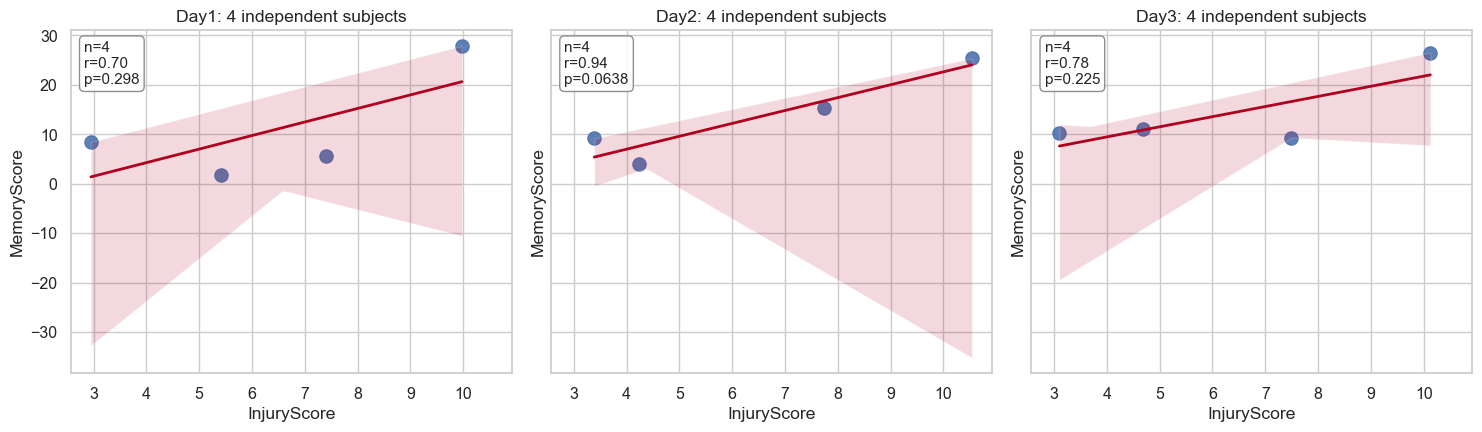

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
day_reports = []

for ax, (day, day_data) in zip(axes, brain.groupby("Day", sort=True)):
    day_reports.append(
        plot_and_report_pearson(
            day_data,
            "InjuryScore",
            "MemoryScore",
            title=f"{day}: 4 independent subjects",
            ax=ax,
        )
    )

fig.tight_layout()
display(pd.DataFrame(day_reports))


,Subject,InjuryScore,MemoryScore
0,subject1,3.146,9.294
1,subject2,4.775,5.596
2,subject3,7.546,10.107
3,subject4,10.213,26.619


,analysis,n,r,df,p,95% CI lower,95% CI upper
0,Subject-level means: one point per subject,4,0.832,2,0.168,-0.643,0.996


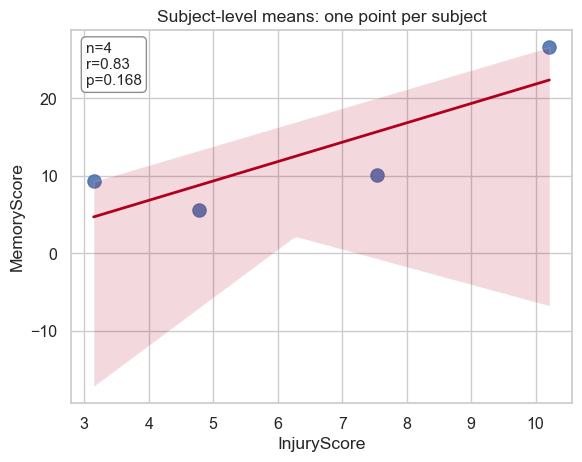

In [17]:
subject_mean = (
    brain.groupby("Subject", as_index=False)[["InjuryScore", "MemoryScore"]]
    .mean()
    .sort_values("Subject")
)

display(subject_mean)

fig, ax = plt.subplots(figsize=(6, 4.8))
mean_report = plot_and_report_pearson(
    subject_mean,
    "InjuryScore",
    "MemoryScore",
    title="Subject-level means: one point per subject",
    ax=ax,
)
fig.tight_layout()
display(mean_report.to_frame().T)


,analysis,n,r,df,p,95% CI lower,95% CI upper
0,Naive pooled analysis: 12 rows treated as inde...,12,0.776,10,0.003,0.365,0.934


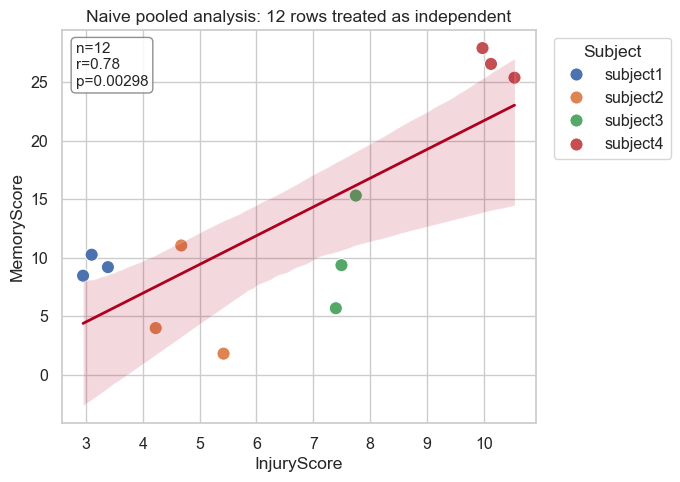

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
pooled_report = plot_and_report_pearson(
    brain,
    "InjuryScore",
    "MemoryScore",
    title="Naive pooled analysis: 12 rows treated as independent",
    ax=ax,
    hue="Subject",
)
fig.tight_layout()
display(pooled_report.to_frame().T)


### Discussion: why do the three answers differ?

The pooled analysis has more rows, so its p value can become much smaller. But those 12 rows are not 12 independent people; they are repeated measurements from 4 subjects.

规范解释：

- 每天单独分析：每次只有 4 个独立观测，CI 会非常宽。
- 先按 Subject 求均值：仍然只有 4 个独立观测，但分析单位更清楚。
- 直接合并 12 行：违反独立性，把重复测量当作独立样本，容易夸大证据强度。

更合适的后续方法通常是 repeated-measures correlation、mixed-effects model，或先明确分析单位后再做相关分析。


## Reporting template

Pearson 相关结果可以这样写：

> A Pearson correlation analysis showed a negative linear association between miles per gallon and horsepower, $r(30)=-0.78$, $p<0.001$, 95% CI $[-0.89,-0.59]$.

中文汇报：

> Pearson 相关分析显示，`mpg` 与 `hp` 存在较强的负向线性相关，$r(30)=-0.78$，$p<0.001$，95% CI $[-0.89,-0.59]$。

注意：不要写成“p 很小，所以相关很强”。强弱来自 $r$ 和置信区间；显著性来自 p 值。
